# Freight Market Dynamics - Dry Van Market - VAR Models

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import grangercausalitytests

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

from statsmodels.tools.eval_measures import rmse, aic
from statsmodels.tsa.api import VAR

import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Not use scientific notation

pd.set_option("display.float_format", "{:.4f}".format)

## Load data

In [6]:
df = pd.read_parquet("data/data_for_model.parquet") 
df = df[["id", "week", "r", "c", "f"]]

In [8]:

# Save as Stata file
df.to_stata('data/data_for_model.dta')


### Granger- Causality test

The basis behind Vector AutoRegression is that each of the time series in the  system influences each other. That is, you can predict the series with past 
values of itself along with other series in the system.

Using Granger’s Causality Test, it’s possible to test this relationship before even building the model.
* Ho: past values of time series (X) DO NOT cause the other series (Y).

In [5]:
def granger_causation_matrix(data, columns, p=4, test='ssr_chi2test', verbose=False):
    """
    Returns a matrix of min p-values from Granger tests for all ordered pairs.
    Rows are Y, columns are X (testing X -> Y). Smaller p => stronger evidence of Granger causality.
    """
    out_granger = pd.DataFrame(np.ones((len(columns), len(columns))),
                       columns=[v + "_x" for v in columns],
                       index=[v + "_y" for v in columns])
    for y in columns:
        for x in columns:
            if y == x: 
                out_granger.loc[y + "_y", x + "_x"] = np.nan
                continue
            # statsmodels expects first column = Y, second = X
            sub = data[[y, x]].dropna()
            if len(sub) <= p + 2:
                out_granger.loc[y + "_y", x + "_x"] = np.nan
                continue
            res = grangercausalitytests(sub, maxlag=p, verbose=False)
            pvals = [res[i+1][0][test][1] for i in range(p)]
            if verbose:
                print(f"Y={y}, X={x}, p-values by lag 1..{p}: {np.round(pvals,4)}")
            out_granger.loc[y + "_y", x + "_x"] = np.min(pvals)
    return out_granger


### Granger causality - One market area

In [6]:
vars_ = ['r','c','f']
df1 = df[df['id'] == 'CA_LAX'].sort_values('week')
gc_CA_LAX = granger_causation_matrix(df1[['r','c','f']], vars_, p=4)
gc_CA_LAX

,r_x,c_x,f_x
r_y,NaN,0.0000,0.0006
c_y,0.0074,NaN,0.0000
f_y,0.0000,0.0001,NaN


### Granger causality - All market areas

In [7]:
vars_ = ['r','c','f']
p = 4
alpha = 0.05

mats = {}
for group_id, d in df.sort_values('week').groupby('id'):
    mat = granger_causation_matrix(d[['r','c','f']], vars_, p=p)
    mats[group_id] = mat

# Stack into long form to summarize across ids
long = (pd.concat({k: v for k, v in mats.items()}, names=['id'])
          .stack().reset_index())
long.columns = ['id', 'y', 'x', 'pvalue']

# Share of panels where X -> Y is significant at alpha
share_sig = (long.assign(sig=lambda x: x['pvalue'] < alpha)
                  .groupby(['y','x'])['sig'].mean()
                  .unstack())
print("Fraction of IDs with significant Granger causality (p<0.05):")
share_sig

Fraction of IDs with significant Granger causality (p<0.05):


x,c_x,f_x,r_x
y,,,
c_y,NaN,1.0000,0.9259
f_y,1.0000,NaN,1.0000
r_y,1.0000,0.9630,NaN


### Stationary Test (ADF Test)

VAR model requires the time series you want to forecast to be stationary - ADF Test.

Differencing reduces the length of the series by 1 and since all the  time series has to be of the same length, you need to difference all the seriesin the system if you choose to difference at all.

In [8]:
## ADF test just for CA_LAX (df1)

id_test = 'CA_LAX'

def adf_one(series, autolag='AIC'):
    s = pd.to_numeric(pd.Series(series), errors='coerce').dropna()
    stat, p, nlags, nobs, crit, _ = adfuller(s, autolag=autolag)
    return {
        "test_stat": round(stat, 4),
        "pvalue": round(p, 4),
        "nlags": int(nlags),
        "nobs": int(nobs),
        "cv_1%": round(crit["1%"], 3),
        "cv_5%": round(crit["5%"], 3),
        "cv_10%": round(crit["10%"], 3),
        "stationary_5%": p < 0.05
    }

results = {col: adf_one(df1[col]) for col in vars_}
adf_table = pd.DataFrame(results).T

adf_table['id'] = id_test

adf_table

,test_stat,pvalue,nlags,nobs,cv_1%,cv_5%,cv_10%,stationary_5%,id
r,-1.4148,0.5751,3,222,-3.4600,-2.8750,-2.5740,False,CA_LAX
c,-1.2232,0.6635,15,210,-3.4620,-2.8750,-2.5740,False,CA_LAX
f,-0.6915,0.8489,1,224,-3.4600,-2.8750,-2.5740,False,CA_LAX


In [9]:
def adf_one(series, autolag='AIC'):
    s = pd.to_numeric(pd.Series(series), errors='coerce').dropna()
    stat, p, nlags, nobs, crit, _ = adfuller(s, autolag=autolag)
    return dict(test_stat=round(stat,4), pvalue=round(p,4),
                nlags=int(nlags), nobs=int(nobs),
                cv_1=round(crit['1%'],3), cv_5=round(crit['5%'],3),
                cv_10=round(crit['10%'],3), stationary_5=(p<0.05))

vars_ = ['r','c','f']
rows = []

for group_id, g in df.sort_values('week').groupby('id'):
    for v in vars_:
        rows.append({'id': group_id, 'var': v, **adf_one(g[v])})
panel_adf = pd.DataFrame(rows)

# share of IDs that are stationary at 5%
share = (panel_adf.groupby('var')['stationary_5']
                   .mean().rename('share_stationary')).reset_index()
print(share.round(3))

panel_adf

  var  share_stationary
0   c            0.0000
1   f            0.0000
2   r            0.0000


,id,var,test_stat,pvalue,nlags,nobs,cv_1,cv_5,cv_10,stationary_5
0,CA_LAX,r,-1.4148,0.5751,3,222,-3.4600,-2.8750,-2.5740,False
1,CA_LAX,c,-1.2232,0.6635,15,210,-3.4620,-2.8750,-2.5740,False
2,CA_LAX,f,-0.6915,0.8489,1,224,-3.4600,-2.8750,-2.5740,False
3,CA_ONT,r,-1.5349,0.5162,7,218,-3.4610,-2.8750,-2.5740,False
4,CA_ONT,c,-1.4928,0.5371,4,221,-3.4600,-2.8750,-2.5740,False
...,...,...,...,...,...,...,...,...,...,...
76,WI_GRE,c,0.4974,0.9848,3,222,-3.4600,-2.8750,-2.5740,False
77,WI_GRE,f,-0.6904,0.8492,4,221,-3.4600,-2.8750,-2.5740,False
78,WI_MIL,r,-1.5404,0.5134,3,222,-3.4600,-2.8750,-2.5740,False
79,WI_MIL,c,1.0619,0.9949,5,220,-3.4600,-2.8750,-2.5740,False


### ADF test results:
* Data are NON-stationary.
* IDs fail ADF and panel tests fail → We should difference or detrend:

### Compute First difference per id (KMA)

In [10]:
df.sort_values(by=['id', 'week'], inplace = True)

# Compute first differences
df[['r_d','c_d','f_d']] =df.groupby('id')[['r','c','f']].diff().dropna()

df_diff = df.dropna(subset=['r_d','c_d','f_d']).copy()

In [11]:
df_diff

,id,week,r,c,f,r_d,c_d,f_d
27,CA_LAX,2019-01-13,0.6649,0.1520,-1.2101,-0.0995,0.0916,-0.0331
54,CA_LAX,2019-01-20,0.5722,0.2376,-1.2014,-0.0927,0.0856,0.0087
81,CA_LAX,2019-01-27,0.5459,0.3180,-1.2075,-0.0263,0.0804,-0.0061
108,CA_LAX,2019-02-03,0.4743,0.3940,-1.2114,-0.0716,0.0759,-0.0039
135,CA_LAX,2019-02-10,0.4639,0.4659,-1.2279,-0.0104,0.0720,-0.0165
...,...,...,...,...,...,...,...,...
5993,WI_MIL,2023-04-02,0.7877,0.2474,-0.6548,-0.0096,-0.0797,-0.0238
6020,WI_MIL,2023-04-09,0.7795,0.1606,-0.6324,-0.0082,-0.0867,0.0223
6047,WI_MIL,2023-04-16,0.7595,0.0655,-0.6435,-0.0200,-0.0951,-0.0111
6074,WI_MIL,2023-04-23,0.7234,-0.0398,-0.6435,-0.0360,-0.1053,0.0000


In [12]:
# Re-set vars for differenced data
vars_ = ['r_d','c_d','f_d']
rows = []

# Compute ADF test
for group_id, g in df_diff.sort_values('week').groupby('id'):
    for v in vars_:
        rows.append({'id': group_id, 'var': v, **adf_one(g[v])})
        
panel_adf = pd.DataFrame(rows)

# share of IDs that are stationary at 5%
share = (panel_adf.groupby('var')['stationary_5']
                   .mean().rename('share_stationary')).reset_index()

print(share.round(3))

panel_adf


   var  share_stationary
0  c_d            0.3700
1  f_d            1.0000
2  r_d            1.0000


,id,var,test_stat,pvalue,nlags,nobs,cv_1,cv_5,cv_10,stationary_5
0,CA_LAX,r_d,-6.3889,0.0000,2,222,-3.4600,-2.8750,-2.5740,True
1,CA_LAX,c_d,-3.6941,0.0042,15,209,-3.4620,-2.8750,-2.5740,True
2,CA_LAX,f_d,-8.4771,0.0000,0,224,-3.4600,-2.8750,-2.5740,True
3,CA_ONT,r_d,-8.7899,0.0000,0,224,-3.4600,-2.8750,-2.5740,True
4,CA_ONT,c_d,-3.6413,0.0050,15,209,-3.4620,-2.8750,-2.5740,True
...,...,...,...,...,...,...,...,...,...,...
76,WI_GRE,c_d,0.6332,0.9884,3,221,-3.4600,-2.8750,-2.5740,False
77,WI_GRE,f_d,-5.7299,0.0000,3,221,-3.4600,-2.8750,-2.5740,True
78,WI_MIL,r_d,-7.2169,0.0000,2,222,-3.4600,-2.8750,-2.5740,True
79,WI_MIL,c_d,0.7916,0.9915,4,220,-3.4600,-2.8750,-2.5740,False


#### Note that capacity is still not fully stationary accross all KMAs. Need to diferentiate once again.


### Compute second difference per id (KMA)

In [13]:
# Compute second differences
df_diff[['r_d2','c_d2','f_d2']] =df_diff.groupby('id')[['r_d','c_d','f_d']].diff().dropna()

df_diff_2 = df_diff.dropna(subset=['r_d2','c_d2','f_d2']).copy()

In [14]:
# Re-set vars for differenced data
vars_ = ['r_d2','c_d2','f_d2']
rows = []

for group_id, g in df_diff_2.sort_values('week').groupby('id'):
    for v in vars_:
        rows.append({'id': group_id, 'var': v, **adf_one(g[v])})
        
panel_adf = pd.DataFrame(rows)


# share of IDs that are stationary at 5%
share = (panel_adf.groupby('var')['stationary_5']
                   .mean().rename('share_stationary')).reset_index()
print(share.round(3))
panel_adf


    var  share_stationary
0  c_d2            0.7780
1  f_d2            1.0000
2  r_d2            1.0000


,id,var,test_stat,pvalue,nlags,nobs,cv_1,cv_5,cv_10,stationary_5
0,CA_LAX,r_d2,-5.3093,0.0000,15,208,-3.4620,-2.8760,-2.5740,True
1,CA_LAX,c_d2,-3.3886,0.0114,15,208,-3.4620,-2.8760,-2.5740,True
2,CA_LAX,f_d2,-9.7486,0.0000,5,218,-3.4610,-2.8750,-2.5740,True
3,CA_ONT,r_d2,-5.4176,0.0000,15,208,-3.4620,-2.8760,-2.5740,True
4,CA_ONT,c_d2,-3.0010,0.0348,14,209,-3.4620,-2.8750,-2.5740,True
...,...,...,...,...,...,...,...,...,...,...
76,WI_GRE,c_d2,-2.4482,0.1286,2,221,-3.4600,-2.8750,-2.5740,False
77,WI_GRE,f_d2,-10.3156,0.0000,5,218,-3.4610,-2.8750,-2.5740,True
78,WI_MIL,r_d2,-8.0754,0.0000,11,212,-3.4620,-2.8750,-2.5740,True
79,WI_MIL,c_d2,-0.9902,0.7568,3,220,-3.4600,-2.8750,-2.5740,False


## PVAR FIXED Effects

In [31]:
# 1) Sort and within-demean by id
W = (df_diff_2
     .set_index(['id','week'])[vars_]
     .sort_index()
     .groupby(level=0)
     .apply(lambda x: x - x.mean())   # remove unit fixed effects
     .reset_index(level=0, drop=True))

display (W.tail())

# # 1) Sort and within-demean by id
# W = (df_diff
#      .set_index(['id','week'])[vars_])


# 2) Fit pooled VAR with p=2
var = VAR(W.dropna())
res = var.fit(2, trend = 'c')
print(res.summary())


r_d2    c_d2    f_d2
id     week                              
WI_MIL 2023-04-02  0.0061 -0.0055 -0.0099
       2023-04-09  0.0011 -0.0066  0.0460
       2023-04-16 -0.0120 -0.0079 -0.0336
       2023-04-23 -0.0163 -0.0097  0.0109
       2023-04-30  0.0238 -0.0121 -0.0002

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 25, Sep, 2025
Time:                     15:48:40
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -27.6195
Nobs:                     6046.00    HQIC:                  -27.6347
Log likelihood:           57848.6    FPE:                9.88263e-13
AIC:                     -27.6428    Det(Omega_mle):     9.84838e-13
--------------------------------------------------------------------
Results for equation r_d2
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const          -0.000014         0.000339           -0.040           0.968
L1.r_d2        -0.099540         0.012248           -8.127           0.000
L1.c_d2         0.378780         0.242848            1.560           0.119
L1.f_d2   

### Model Diagnostics - Correlation Matirx of residulas (contemporaneous shocks)

* Near-zero off-diagonals ⇒ shocks are almost uncorrelated contemporaneously. That’s good news for identification: Cholesky IRFs will be less sensitive to variable ordering.
* Shocks across equations are weakly correlated contemporaneously -> Compute IRF Cholesky

### Model Diagnostics - VAR Residual normality test

In [16]:
nt = res.test_normality()     # VARResults -> NormalityTestResults

# Pretty table (if your statsmodels version supports it)
try:
    print(nt.summary())
except Exception:
    # Manual print
    print(f"Normality (joint)  : chi2({nt.df}) = {nt.stat:.3f},  p = {nt.pvalue:.4g}")
    # If available, components:
    if hasattr(nt, "skewness"):
        print(f"  Skewness         : chi2 = {nt.skewness.stat:.3f}, p = {nt.skewness.pvalue:.4g}")
    if hasattr(nt, "kurtosis"):
        print(f"  Kurtosis         : chi2 = {nt.kurtosis.stat:.3f}, p = {nt.kurtosis.pvalue:.4g}")


normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.995e+05          12.59   0.000  6
----------------------------------------


##### Results indicate to reject normality of the residuals. But it means?
* Forecasting: Lack of normality does not invalidate forecasting from VAR — OLS estimates are still consistent.

* IRFs: Impulse responses remain valid, but confidence bands may be less reliable.

### Model Diagnostics - VAR autocorrelation test

In [17]:
# Run DW on VAR residuals
out = durbin_watson(res.resid)

# Use the endogenous variable names from the VAR, not df.columns
for col, val in zip(res.names, out):
    print(col, ':', round(val, 2))


r_d2 : 2.11
c_d2 : 1.98
f_d2 : 2.08


DW Tests indicates for all 3 variables that residuals are not autocrrelated $\rightarrow$ DW close to 2

### Model Diagnostics - VAR Stability Test

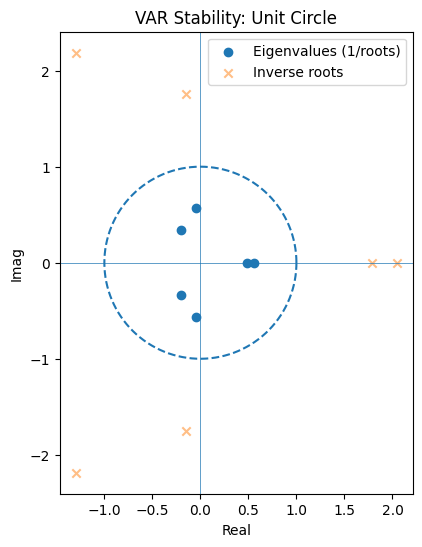

In [18]:
inv_roots = res.roots                    # inverse roots from statsmodels
eigvals   = 1 / inv_roots                # companion-matrix eigenvalues

theta = np.linspace(0, 2*np.pi, 512)

fig, ax = plt.subplots(figsize=(8,6))

# unit circle
ax.plot(np.cos(theta), np.sin(theta), linestyle='--')

# plot eigenvalues
ax.scatter(eigvals.real, eigvals.imag, marker='o', label='Eigenvalues (1/roots)')

# (optional) also show inverse roots (should be OUTSIDE unit circle if stable)
ax.scatter(inv_roots.real, inv_roots.imag, marker='x', alpha=0.5, label='Inverse roots')

ax.axhline(0, linewidth=0.5); ax.axvline(0, linewidth=0.5)
ax.set_aspect('equal', 'box')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
ax.set_title('VAR Stability: Unit Circle')
ax.legend()
plt.show()


### IRF  (Stationary VAR)

* Interpretation:
    * if the IRFs are positive, it indicates a positive shock on the variable. This shock will die out after a few time periods and IRFs will fall back to zero in a Stationary VAR. 
    * if the IRFs are negative, it indicates a negative shock and the IRfs will rise back to zero after a few periods in a stationary VAR model.

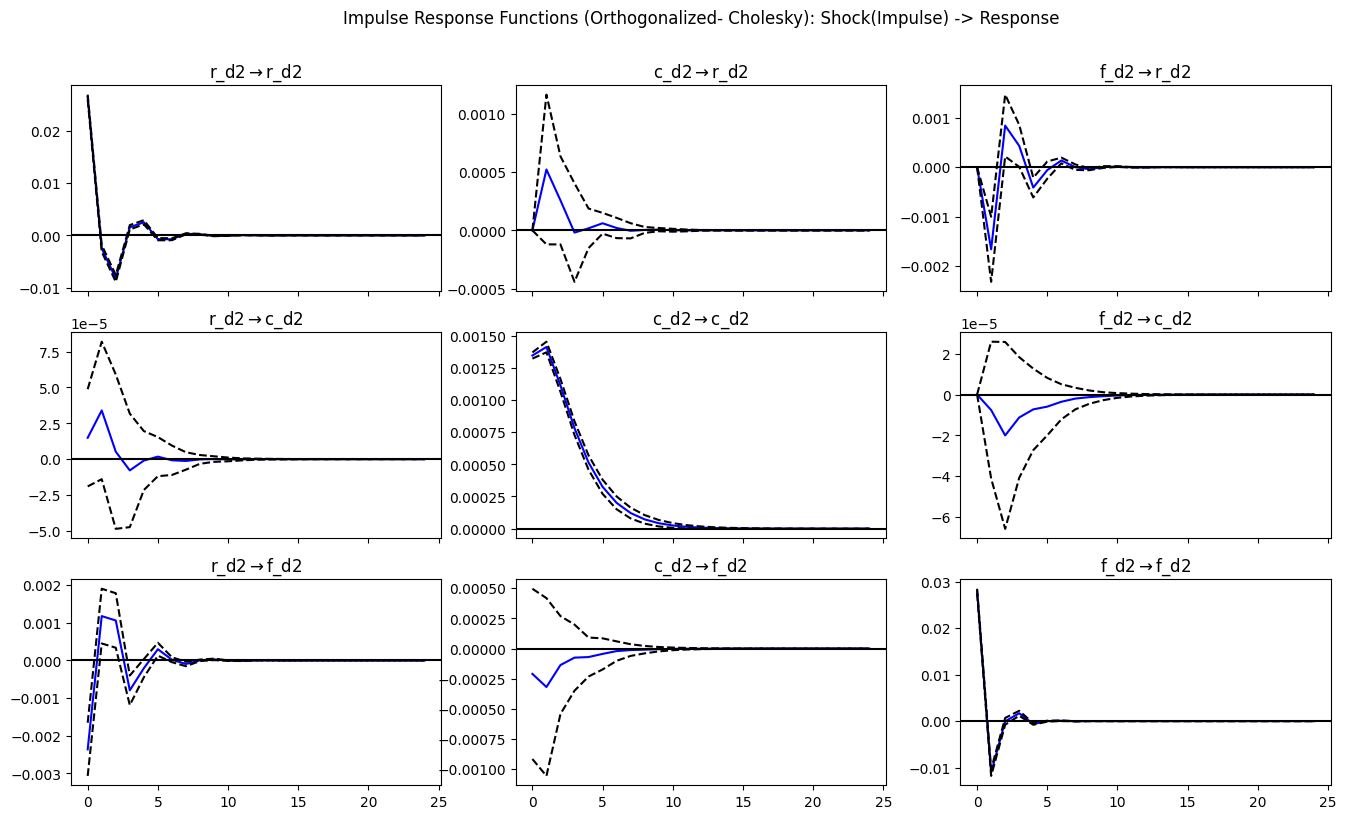

In [23]:
# Plot individual IRFs 

# irf = res.irf(periods=24) 
# irf.plot(impulse='c_d2', response='r_d2', plot_stderr=True, stderr_type='mc', repl=1000)

# plt.title('Response of RATE to a shock in CAPACITY')
# plt.show()

# Access the numerical results of the IRFs
# print("IRF values (first 5 periods for response of rate to capacity shock):")
# print(irf.irfs[:, 0, 1][:5]) # Accessing specific IRF values

### Plot All IRs
irf = res.irf(periods=24) 

# Remember that Cholesky decomposition is default for orth=True) - assuming a specific ordering of variables.
irf.plot(orth=True, figsize=(14,8)) # Plot IRFs, non-orthogonalized - socks are not assumed to be uncorrelated.

# plt.suptitle('Impulse Response Functions (Non-Orthogonalized): Shock(Impulse) -> Response', y=1.02)
plt.suptitle('Impulse Response Functions (Orthogonalized- Cholesky): Shock(Impulse) -> Response', y=1.02)
plt.show()

### IRF Pairs - Given normality issue, we can plot IRF with percentile bonds

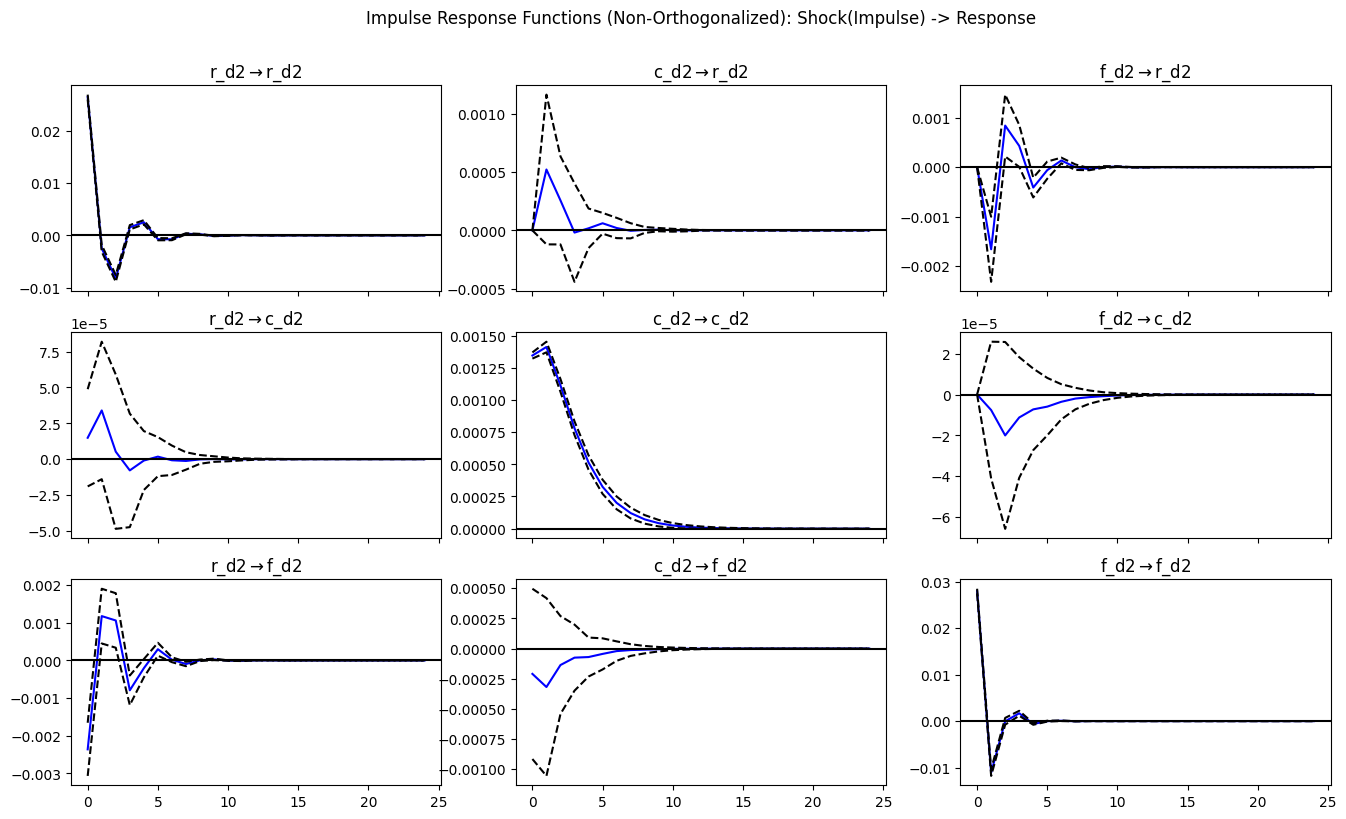

In [24]:
# Robust IRF error bands via bootstrap
irf = res.irf(periods = 24)                       # your fitted VAR(2) -> res
lower, upper = irf.errband_mc(repl=1000, signif=0.05)  # percentile bands
irf.plot(orth=True, figsize=(14,8))                     # plot IRFs

# Remember that Cholesky decomposition is default for orth=True)
plt.suptitle('Impulse Response Functions (Non-Orthogonalized): Shock(Impulse) -> Response', y=1.02)
plt.show()

## VAR Fittred Outputs

Notice that VAR treats the stacked panel as one long series, so res.plot()/res.resid mix all IDs together

In [30]:
# # Access residuals and fitted values
# var_resid = res.resid.reset_index()       
# var_pred  = res.fittedvalues

# ## Compute predictions accuracy metrics per id
# var_pred = var_pred.add_suffix("_pred")

# # ensure both are sorted and indexed the same way
# W = W.sort_index()
# var_pred = var_pred.sort_index()

# # inner join on the index (id, week)
# df_accuracy = W.join(var_pred, how='inner')
# df_accuracy


In [ ]:
# def overall_accuracy(df, vars=("r", "c", "f"), actual_suffix="_d2", pred_suffix="_d2_pred"):
#     results = {}
    
#     for v in vars:
#         a_col = f"{v}{actual_suffix}"
#         p_col = f"{v}{pred_suffix}"
        
#         actual = df[a_col].values
#         pred   = df[p_col].values
        
#         # avoid division by zero for MAPE
#         mask = actual != 0
#         mape = np.mean(np.abs((pred[mask] - actual[mask]) / actual[mask]))
#         rmse = np.sqrt(np.mean((pred - actual) ** 2))
        
#         results[v] = {"MAPE": mape, "RMSE": rmse}
    
#     return pd.DataFrame(results).T  # nice table form

# metrics_overall = overall_accuracy(df_accuracy)
# metrics_overall
# # 

,MAPE,RMSE
r,2.6447,0.0264
c,0.7755,0.0013
f,2.5404,0.0281


## VAR Forecasting - Last 2 rows

In [32]:
lag_order = res.k_ar
print(lag_order) 

# Input data for forecasting -> 2 last rows 
forecast_input = W.values[-lag_order:]
print(forecast_input)

# Forecast

nobs = 2
fc = res.forecast(y=forecast_input, steps=nobs) # nobs defined at top of program
W_forecast = pd.DataFrame(fc, index=W.index[-nobs:], columns=W.columns + '_2d')
W_forecast

2
[[-0.01626114 -0.00969561  0.01092166]
 [ 0.02378836 -0.01211716 -0.00018504]]


r_d2_2d  c_d2_2d  f_d2_2d
id     week                                 
WI_MIL 2023-04-23  -0.0000  -0.0100   0.0006
       2023-04-30  -0.0092  -0.0072   0.0028

### VAR De -differentiate 

In [ ]:
vars_ = ['r','c','f']

# levels with a proper MultiIndex and sorted
levels = (df
          .set_index(['id','week'])
          .sort_index())[vars_]

levels

In [ ]:
# Δx and Δ²x in the training window
d1_train = levels.groupby(level=0).diff() # First difference
d2_train = d1_train.groupby(level=0).diff() # Second difference

# per-id mean of Δ²x (used to re-add the mean if W was demeaned)
means_d2 = d2_train.groupby(level=0).mean()   # index: id, cols: r,c,f
means_d2

In [ ]:
def to_base_name(col):
    # strip any suffix that came from differencing labels
    for pat in ['_d2_2d', '_d2d2', '_2d', '_d2', '_d']:
        col = col.replace(pat, '')
    return col

d2_fc = W_forecast.copy()
d2_fc.columns = [to_base_name(c) for c in d2_fc.columns]   # -> ['r','c','f']
# ensure MultiIndex ['id','week'] and sorted
d2_fc = d2_fc.sort_index()
d2_fc

In [ ]:
import pandas as pd

def invert_var2_panel(levels_train, d2_forecast, vars_, demeaned_d2=None):
    """
    levels_train: DataFrame with index ['id','week'], columns = vars_ (levels)
    d2_forecast : DataFrame with index ['id','week_future'], columns = vars_ (Δ²x forecasts)
    demeaned_d2: per-id mean of Δ²x (DataFrame index=id, columns=vars_) or None
    """
    levels_train = levels_train.sort_index()
    d2_forecast  = d2_forecast.sort_index()

    # If W was demeaned, add back the mean of Δ²x per id
    if demeaned_d2 is not None:
        d2_forecast = d2_forecast.copy()
        for gid, g in d2_forecast.groupby(level=0):
            d2_forecast.loc[gid, vars_] = g[vars_].values + demeaned_d2.loc[gid, vars_].values

    # anchors: x_T and Δx_T per id
    last_level = levels_train.groupby(level=0).tail(1)[vars_]       # x_T
    prev_level = levels_train.groupby(level=0).nth(-2)[vars_]        # x_{T-1}
    last_d1    = (last_level.values - prev_level.values)            # Δx_T
    last_d1    = pd.DataFrame(last_d1, index=last_level.index, columns=vars_)

    # build forecasts per id
    outs = []
    for gid, gfc in d2_forecast.groupby(level=0):
        # cumulative sum of Δ²x → Δx
        d1_fore = gfc[vars_].cumsum().add(last_d1.loc[gid].values, axis=1)
        # cumulative sum of Δx → level
        lvl_fore = d1_fore.cumsum().add(last_level.loc[gid].values, axis=1)
        lvl_fore.index = gfc.index
        outs.append(lvl_fore)

    return pd.concat(outs).sort_index()


# If you demeaned W earlier, pass means_d2; otherwise pass None
levels_fc = invert_var2_panel(
    levels_train=levels,
    d2_forecast=d2_fc,         # your Δ²x forecasts with columns ['r','c','f']
    vars_=vars_,
    demeaned_d2=means_d2       # or None
)

levels_fc


## VAR Forecasting - Last 2 rows per id

In [34]:
def panel_var_predict_last_k(W, res, steps=2):
    """
    One-step-ahead predictions for the *last `steps` existing dates* per id.

    Parameters
    ----------
    W   : DataFrame, MultiIndex ['id','week'], columns = endogenous (same used in VAR fit)
    res : statsmodels VARResults (pooled VAR)
    steps : int, number of last existing dates to predict per id (e.g., 2)

    Returns
    -------
    DataFrame with index ['id','week'] and same columns as W,
    containing predictions for those last `steps` existing timestamps.
    """
    W = W.sort_index()
    p = res.k_ar
    cols = W.columns
    out = []

    for gid, g in W.groupby(level=0):
        g = g.sort_index()
        idx = g.index.get_level_values(1)

        # need at least p + steps observations
        if len(g) < p + steps:
            continue

        # we'll predict for t = len(g)-steps ... len(g)-1
        preds = []
        target_idx = []
        for t in range(len(g) - steps, len(g)):
            y0 = g.values[t - p:t]             # previous p actual rows for this id
            fc = res.forecast(y=y0, steps=1)[0] # 1-step ahead for time t
            preds.append(fc)
            target_idx.append(idx[t])

        mi = pd.MultiIndex.from_product([[gid], target_idx], names=['id','week'])
        df_pred = pd.DataFrame(np.vstack(preds), index=mi, columns=cols)
        out.append(df_pred)

    return pd.concat(out).sort_index()


In [35]:
# W is your panel used for the pooled VAR (e.g., second diffs), MultiIndex ['id','week']
# res is the fitted VAR(2)
pred_last2 = panel_var_predict_last_k(W, res, steps=2)
pred_last2


r_d2    c_d2    f_d2
id     week                              
CA_LAX 2023-04-23  0.0085  0.0004 -0.0014
       2023-04-30  0.0013  0.0004 -0.0000
CA_ONT 2023-04-23  0.0068  0.0007 -0.0096
       2023-04-30  0.0057  0.0007 -0.0015
CO_DEN 2023-04-23  0.0140 -0.0007  0.0001
       2023-04-30 -0.0089 -0.0009  0.0017
FL_LAK 2023-04-23 -0.0022  0.0001 -0.0092
       2023-04-30  0.0027  0.0002 -0.0013
GA_ATL 2023-04-23 -0.0007  0.0004 -0.0012
       2023-04-30 -0.0001  0.0005 -0.0000
IL_CHI 2023-04-23  0.0076 -0.0079  0.0259
       2023-04-30  0.0008 -0.0099  0.0047
IL_JOL 2023-04-23  0.0018 -0.0039  0.0060
       2023-04-30  0.0063 -0.0045  0.0004
IN_IND 2023-04-23  0.0053 -0.0023  0.0127
       2023-04-30 -0.0016 -0.0026  0.0021
KY_LEX 2023-04-23 -0.0041 -0.0015 -0.0324
       2023-04-30  0.0012 -0.0018 -0.0019
MI_RAP 2023-04-23  0.0115 -0.0053  0.0294
       2023-04-30  0.0035 -0.0063  0.0037
MO_GIR 2023-04-23 -0.0143 -0.0022  0.0258
       2023-04-30 -0.0005 -0.0027  0.0023
MO_KAN 2023-04-23  0.0078 -0.0008  0.0001
       2023-04-30  0.0012 -0.0008  0.0003
MO_STL 2023-04-23  0.0030 -0.0009 -0.0035
       2023-04-30  0.0063 -0.0009 -0.0010
NC_CHA 2023-04-23  0.0061  0.0001  0.0342
       2023-04-30 -0.0031  0.0002  0.0034
NJ_ELI 2023-04-23 -0.0044 -0.0054  0.0066
       2023-04-30 -0.0001 -0.0065  0.0022
OH_CLE 2023-04-23  0.0012 -0.0019  0.0013
       2023-04-30  0.0052 -0.0021 -0.0007
OH_COL 2023-04-23 -0.0055 -0.0023 -0.0017
       2023-04-30  0.0073 -0.0025 -0.0007
OH_TOL 2023-04-23 -0.0016 -0.0046  0.0082
       2023-04-30  0.0069 -0.0054  0.0008
PA_ALL 2023-04-23 -0.0066 -0.0017 -0.0150
       2023-04-30  0.0046 -0.0020 -0.0013
PA_HAR 2023-04-23 -0.0009 -0.0031  0.0277
       2023-04-30  0.0061 -0.0035  0.0021
SC_GRE 2023-04-23  0.0206  0.0001  0.0974
       2023-04-30 -0.0178  0.0001 -0.0725
TN_MEM 2023-04-23  0.0042  0.0001  0.0152
       2023-04-30  0.0029  0.0002  0.0007
TX_DAL 2023-04-23  0.0016  0.0002  0.0015
       2023-04-30  0.0024  0.0003 -0.0000
TX_FTW 2023-04-23  0.0051  0.0002  0.0330
       2023-04-30  0.0022  0.0003  0.0026
TX_HOU 2023-04-23 -0.0007  0.0000 -0.0036
       2023-04-30  0.0109  0.0001 -0.0018
WI_GRE 2023-04-23  0.0083 -0.0076  0.0342
       2023-04-30  0.0001 -0.0094  0.0047
WI_MIL 2023-04-23  0.0010 -0.0065  0.0078
       2023-04-30  0.0025 -0.0080  0.0024

## VAR Forecasting - H weeks ahead

In [37]:
def panel_var_forecast_last_k(W, res, steps=2):
    """
    Forecast 'steps' periods ahead for every id using a pooled VAR model.
    
    Parameters
    ----------
    W : DataFrame
        Panel data used to fit the VAR, MultiIndex ['id','week'], columns = endogenous (e.g., ['r_d2','c_d2','f_d2'])
    res : statsmodels.tsa.api.VARResults
        Fitted pooled VAR results (same coefficients for all ids)
    steps : int
        Forecast horizon (e.g., 2)
        
    Returns
    -------
    DataFrame
        Forecasts for each id and future weeks, same columns as W
        Index is MultiIndex ['id','week'] for the future dates.
    """
    W = W.sort_index()
    p = res.k_ar
    cols = W.columns
    out = []

    for gid, g in W.groupby(level=0):
        g = g.sort_index()
        if len(g) < p:
            continue  # skip very short panels

        # last p observations for this id -> y0
        y0 = g.values[-p:]                          # shape (p, k)

        # forecast
        fc = res.forecast(y=y0, steps=steps)        # shape (steps, k)

        # build future weekly index for this id
        idx = g.index.get_level_values(1)
        if len(idx) >= 2:
            step = idx[-1] - idx[-2]               # infer frequency (e.g., 7 days)
        else:
            # fallback to 7 days if only 1 row exists (shouldn't happen with p>=2)
            step = pd.Timedelta(days=7)

        future_weeks = [idx[-1] + (h)*step for h in range(1, steps + 1)]
        mi = pd.MultiIndex.from_product([[gid], future_weeks], names=['id', 'week'])

        df_fc = pd.DataFrame(fc, index=mi, columns=cols)
        out.append(df_fc)

    return pd.concat(out).sort_index()

# ---Forecast H weeks ahead -- 
H = 2
W_forecast_all = panel_var_forecast_last_k(W, res, steps=H)
W_forecast_all


r_d2    c_d2    f_d2
id     week                              
CA_LAX 2023-05-07 -0.0062  0.0004  0.0003
       2023-05-14  0.0002  0.0002 -0.0001
CA_ONT 2023-05-07 -0.0085  0.0006  0.0024
       2023-05-14 -0.0022  0.0004 -0.0007
CO_DEN 2023-05-07 -0.0051 -0.0009  0.0005
       2023-05-14  0.0025 -0.0007 -0.0003
FL_LAK 2023-05-07 -0.0148  0.0001  0.0039
       2023-05-14 -0.0042  0.0000 -0.0009
GA_ATL 2023-05-07 -0.0086  0.0005  0.0008
       2023-05-14 -0.0004  0.0003 -0.0003
IL_CHI 2023-05-07 -0.0046 -0.0129 -0.0013
       2023-05-14 -0.0093 -0.0093  0.0041
IL_JOL 2023-05-07 -0.0056 -0.0055  0.0015
       2023-05-14 -0.0035 -0.0039  0.0008
IN_IND 2023-05-07  0.0030 -0.0030 -0.0025
       2023-05-14 -0.0040 -0.0021  0.0020
KY_LEX 2023-05-07 -0.0026 -0.0019  0.0064
       2023-05-14 -0.0051 -0.0014 -0.0015
MI_RAP 2023-05-07 -0.0098 -0.0078 -0.0027
       2023-05-14 -0.0013 -0.0056  0.0026
MO_GIR 2023-05-07 -0.0022 -0.0033 -0.0022
       2023-05-14 -0.0012 -0.0024  0.0016
MO_KAN 2023-05-07 -0.0002 -0.0008 -0.0003
       2023-05-14 -0.0062 -0.0006  0.0011
MO_STL 2023-05-07 -0.0082 -0.0010  0.0021
       2023-05-14 -0.0022 -0.0007 -0.0003
NC_CHA 2023-05-07 -0.0045  0.0001 -0.0056
       2023-05-14 -0.0016  0.0000  0.0025
NJ_ELI 2023-05-07 -0.0065 -0.0080  0.0013
       2023-05-14 -0.0024 -0.0058  0.0012
OH_CLE 2023-05-07 -0.0043 -0.0024  0.0021
       2023-05-14 -0.0032 -0.0017  0.0000
OH_COL 2023-05-07 -0.0031 -0.0029  0.0018
       2023-05-14 -0.0048 -0.0021  0.0005
OH_TOL 2023-05-07 -0.0033 -0.0066  0.0009
       2023-05-14 -0.0095 -0.0047  0.0021
PA_ALL 2023-05-07  0.0010 -0.0022  0.0033
       2023-05-14 -0.0077 -0.0015  0.0001
PA_HAR 2023-05-07 -0.0031 -0.0042 -0.0032
       2023-05-14 -0.0029 -0.0030  0.0024
SC_GRE 2023-05-07  0.0005 -0.0001 -0.0056
       2023-05-14 -0.0046 -0.0000  0.0190
TN_MEM 2023-05-07 -0.0026  0.0001 -0.0022
       2023-05-14 -0.0029  0.0001  0.0013
TX_DAL 2023-05-07  0.0019  0.0003 -0.0010
       2023-05-14 -0.0099  0.0002  0.0018
TX_FTW 2023-05-07  0.0014  0.0003 -0.0064
       2023-05-14 -0.0043  0.0002  0.0031
TX_HOU 2023-05-07 -0.0049  0.0000  0.0013
       2023-05-14 -0.0009  0.0000 -0.0004
WI_GRE 2023-05-07 -0.0017 -0.0122 -0.0022
       2023-05-14 -0.0036 -0.0088  0.0035
WI_MIL 2023-05-07 -0.0000 -0.0100  0.0006
       2023-05-14 -0.0092 -0.0072  0.0028

### VAR was estimated wih 2 diffs -> need to bring values to LEVEL

In [38]:
def invert_var2_at_dates(levels, d2_forecast, vars_, demeaned_d2=None):
    """
    Invert Δ²x forecasts to LEVEL forecasts at the SAME dates as the forecasts.

    Parameters
    ----------
    levels : DataFrame
        Original levels with MultiIndex ['id','week'] and columns = vars_ (e.g., ['r','c','f']).
        Must contain the two dates immediately before each forecasted date per id.
    d2_forecast : DataFrame
        Forecasts of Δ²x at specific existing dates (the last 1–2 dates per id),
        MultiIndex ['id','week'], columns = vars_ (names must be base level names).
    vars_ : list[str]
        Column names at level scale (['r','c','f']).
    demeaned_d2 : DataFrame or None
        If you demeaned Δ²x by id before fitting, pass per-id mean of Δ²x
        (index=id, columns=vars_) to add back. Otherwise pass None.

    Returns
    -------
    DataFrame with predicted levels at those forecasted dates (same index as d2_forecast).
    """
    levels = levels.sort_index()
    d2f    = d2_forecast.sort_index().copy()

    # add back mean of Δ²x if the training Δ² were demeaned- per id and vars
    if demeaned_d2 is not None:
        for gid, g in d2f.groupby(level=0):
            d2f.loc[gid, vars_] = g[vars_].values + demeaned_d2.loc[gid, vars_].values

    out = []
    for gid, gfc in d2f.groupby(level=0):
        gfc = gfc.copy()
        # full history for this id to get anchors
        lev = levels.loc[gid]        # index = week, cols = vars_
        for t in gfc.index.get_level_values(1):
            # need x_{t-1} and x_{t-2}
            prev = lev.loc[:t].iloc[-2:]         # rows: [t-1, t]
            x_tminus1 = prev.iloc[-1][vars_]     # this is x_{t-1}
            x_tminus2 = prev.iloc[-2][vars_]     # this is x_{t-2}
            d1_tminus1 = x_tminus1 - x_tminus2   # Δx_{t-1}
            d2_t_hat = gfc.loc[(gid, t), vars_]  # forecasted Δ²x_t
            d1_t_hat = d1_tminus1 + d2_t_hat     # Δx_t
            x_t_hat  = x_tminus1 + d1_t_hat      # x_t
            out.append(pd.DataFrame([x_t_hat.values],
                                    index=pd.MultiIndex.from_tuples([(gid, t)],
                                    names=['id','week']),
                                    columns=vars_))
    return pd.concat(out).sort_index()


In [ ]:
# levels: original level data df
levels = (df.set_index(['id','week'])
            .sort_index()[['r','c','f']])

# get forecast rows
# Make sure d2_forecast columns are the base names ['r','c','f'].
d2_forecast = pred_last2.copy()
rename_map = {c: c.replace('_d2','') for c in d2_forecast.columns}
d2_forecast = d2_forecast.rename(columns=rename_map)

# If you demeaned Δ²x in training:
d1_train = levels.groupby(level=0).diff()
d2_train = d1_train.groupby(level=0).diff()
means_d2 = d2_train.groupby(level=0).mean()     # per-id mean of Δ²x
# If you did NOT demean, set means_d2 = None

# invert to levels at those same dates
levels_pred_at_dates = invert_var2_at_dates(
    levels=levels,
    d2_forecast=d2_forecast,
    vars_=['r','c','f'],
    demeaned_d2=means_d2   # or None
    #demeaned_d2=None
)

# Compare to actuals at those dates:
compare = (levels.loc[levels_pred_at_dates.index]
                    .join(levels_pred_at_dates, lsuffix='_actual', rsuffix='_pred'))
compare.tail(6)


r_actual  c_actual  f_actual  r_pred  c_pred  f_pred
id     week                                                            
TX_HOU 2023-04-23    0.4936    1.6003   -0.6334  0.4779  1.5970 -0.6368
       2023-04-30    0.4826    1.5971   -0.6334  0.4824  1.5938 -0.6350
WI_GRE 2023-04-23    0.6774    0.6128   -0.5832  0.6549  0.4897 -0.5490
       2023-04-30    0.6527    0.4827   -0.5832  0.6281  0.3427 -0.5785
WI_MIL 2023-04-23    0.7234   -0.0398   -0.6435  0.6886 -0.1521 -0.6356
       2023-04-30    0.7114   -0.1577   -0.6435  0.7021 -0.2841 -0.6409

### VAR model accuracy metrics

In [53]:
def overall_accuracy(df, vars=("r", "c", "f"), actual_suffix="_actual", pred_suffix="_pred"):
    results = {}
    
    df = df.copy()

    for v in vars:
        a_col = f"{v}{actual_suffix}"
        p_col = f"{v}{pred_suffix}"
        
        actual = df[a_col].values
        pred   = df[p_col].values
        
        # avoid division by zero for MAPE
        mask = actual != 0
        mape = np.mean(np.abs((pred[mask] - actual[mask]) / actual[mask]))
        rmse = np.sqrt(np.mean((pred - actual) ** 2))
        
        results[v] = {"MAPE": mape, "RMSE": rmse}
    
    return pd.DataFrame(results).T  # nice table form

metrics_overall = overall_accuracy(compare)
metrics_overall


,MAPE,RMSE
r,0.3929,0.0178
c,0.2520,0.0662
f,0.0196,0.0316


## VARX(2)

* VARMAX in statsmodels is not panel-aware. It expects one multivariate time series: index = a single time axis.

In [66]:
W.reset_index()

,id,week,r_d2,c_d2,f_d2
0,CA_LAX,2019-01-20,0.0063,-0.0055,0.0417
1,CA_LAX,2019-01-27,0.0660,-0.0047,-0.0150
2,CA_LAX,2019-02-03,-0.0458,-0.0041,0.0021
3,CA_LAX,2019-02-10,0.0607,-0.0035,-0.0127
4,CA_LAX,2019-02-17,0.0365,-0.0031,0.0199
...,...,...,...,...,...
6043,WI_MIL,2023-04-02,0.0061,-0.0055,-0.0099
6044,WI_MIL,2023-04-09,0.0011,-0.0066,0.0460
6045,WI_MIL,2023-04-16,-0.0120,-0.0079,-0.0336
6046,WI_MIL,2023-04-23,-0.0163,-0.0097,0.0109


In [68]:
import statsmodels.api as sm

gid = "WI_MIL"                          # pick a market
gi = (W.loc[gid]                        # <-- drop the 'id' level; index is 'week'
        .sort_index()
        .loc[:, ['r_d2','c_d2','f_d2']]
        .dropna())

endog = gi[['r_d2','c_d2']].astype(float)
exog  = gi[['f_d2']].astype(float)      # 2-D exog, same index as endog

# sanity checks
assert endog.index.equals(exog.index)
assert endog.shape[0] > 10

mod = sm.tsa.VARMAX(endog=endog, exog=exog, order=(2,0), trend='n')
res = mod.fit(maxiter=1000, disp=False)

print(res.summary())


                           Statespace Model Results                           
Dep. Variable:       ['r_d2', 'c_d2']   No. Observations:                  224
Model:                        VARX(2)   Log Likelihood                1733.091
Date:                Thu, 25 Sep 2025   AIC                          -3440.182
Time:                        19:29:36   BIC                          -3395.831
Sample:                    01-20-2019   HQIC                         -3422.280
                         - 04-30-2023                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):             1.00, 0.19   Jarque-Bera (JB):      16.63, 24632.66
Prob(Q):                        0.32, 0.66   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         0.63, 0.33   Skew:                      -0.39, 2.41
Prob(H) (two-sided):            0.05, 0.00   Kurtosis:                  4.09, 54.15
                          Result

[Text(0.5, 0, 't'), Text(0.5, 1.0, 'Responses to a shock to `r_d2`')]

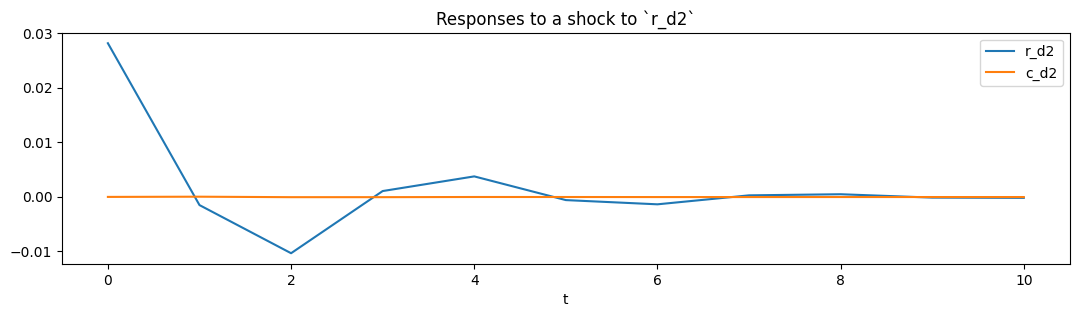

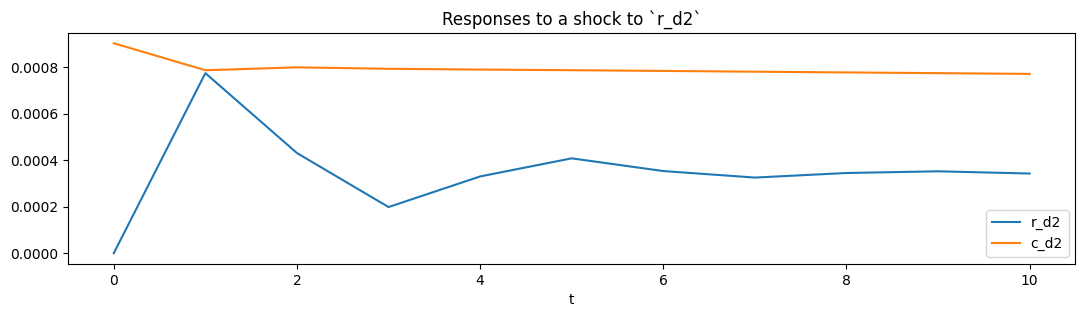

In [75]:
ax = res.impulse_responses(10, orthogonalized=True).plot(figsize=(13,3))
ax.set(xlabel='t',  title='Responses to a shock to `r_d2`')

ax = res.impulse_responses(10, orthogonalized=True, impulse = [0,1]).plot(figsize=(13,3))
ax.set(xlabel='t',  title='Responses to a shock to `r_d2`')

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

H = 10
orth = True
vars_ = list(res.model.endog_names)  # e.g. ['r_d2','c_d2']
k = len(vars_)

# get IRFs
irf_raw = res.impulse_responses(steps=H, orthogonalized=orth)

# normalize to ndarray shape (H+1, k, k)
if isinstance(irf_raw, pd.DataFrame):
    # columns are a MultiIndex: (response, impulse) or similar
    arr = np.empty((H+1, k, k), dtype=float)
    for i, resp in enumerate(vars_):
        for j, imp in enumerate(vars_):
            arr[:, i, j] = irf_raw[(resp, imp)].to_numpy()
else:
    arr = np.asarray(irf_raw)  # already (H+1, k, k)

# plot k×k grid
t = np.arange(H+1)
fig, axes = plt.subplots(k, k, figsize=(4*k, 3*k), sharex=True)
axes = np.atleast_2d(axes)

for i, resp in enumerate(vars_):
    for j, imp in enumerate(vars_):
        ax = axes[i, j]
        ax.plot(t, arr[:, i, j], lw=2)
        ax.axhline(0, color='k', lw=0.8, ls='--')
        ax.set_title(f"{imp} shock → {resp}")
        if i == k-1: ax.set_xlabel("Horizon")
        if j == 0:   ax.set_ylabel(resp)

su = "Orthogonalized" if orth else "Reduced-form"
fig.suptitle(f"VARMAX IRFs ({su})", y=1.02)
fig.tight_layout()
plt.show()


KeyError: ('r_d2', 'r_d2')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# ---- 1) Fit a VAR per id and collect IRFs ----
def average_irf_by_id(
    W,
    vars_=("r_d2","c_d2","f_d2"),
    p=2,                 # VAR lag order
    H=24,                # horizons
    orth=True,           # Cholesky-orthogonalized IRFs; set False for generalized/reduced-form
    trend="c",           # 'n','c','ct','ctt'
    min_extra=10         # require at least p + min_extra rows to fit
):
    irfs, kept_ids = [], []
    k = len(vars_)

    for gid, g in W[vars_].groupby(level=0):
        X = g.droplevel(0).dropna().sort_index()
        if len(X) < p + min_extra:
            continue
        try:
            res = VAR(X).fit(p, trend=trend)
            irf = res.irf(H)
            arr = irf.orth_irfs if orth else irf.irfs   # (H+1, k, k)
            # sanity check on shape
            if arr.shape[1:] != (k, k):
                continue
            irfs.append(arr)
            kept_ids.append(gid)
        except Exception:
            # skip markets that fail to converge
            continue

    if not irfs:
        raise RuntimeError("No IDs produced valid VAR IRFs. Check data length and NaNs.")

    IRF = np.stack(irfs, axis=0)               # (n_ids, H+1, k, k)
    mean_irf = IRF.mean(axis=0)                # (H+1, k, k)
    sd_irf   = IRF.std(axis=0, ddof=1)         # across-ID variability
    se_irf   = sd_irf / np.sqrt(IRF.shape[0])  # std. error of the mean

    return dict(
        mean=mean_irf, sd=sd_irf, se=se_irf,
        ids=kept_ids, horizons=H, vars=list(vars_),
        n_ids=len(kept_ids), orth=orth, p=p
    )

# ---- 2) Plot a k×k grid of average IRFs with bands ----
def plot_irf_grid(irf_pack, band="sd", hide_diag=False):
    """
    band: 'sd' (±1 SD across markets), 'se' (±1 SE of mean), or None (no band)
    hide_diag: True to suppress own-shock panels
    """
    mean = irf_pack["mean"]
    sd   = irf_pack["sd"]
    se   = irf_pack["se"]
    vars_ = irf_pack["vars"]
    H = irf_pack["horizons"]
    k = len(vars_)
    t = np.arange(H+1)

    fig, axes = plt.subplots(k, k, figsize=(3.2*k, 2.6*k), sharex=True)
    axes = np.atleast_2d(axes)

    for i in range(k):
        for j in range(k):
            ax = axes[i, j]
            if hide_diag and i == j:
                ax.axis("off")
                continue

            m = mean[:, i, j]
            ax.plot(t, m, lw=2)

            if band in ("sd","se"):
                b = sd[:, i, j] if band == "sd" else se[:, i, j]
                ax.fill_between(t, m - b, m + b, alpha=0.2)

            ax.axhline(0, lw=0.8, ls="--", color="k")
            if i == k-1:
                ax.set_xlabel("Horizon")
            if j == 0:
                ax.set_ylabel(vars_[i])
            ax.set_title(f"{vars_[j]} → {vars_[i]}", fontsize=10)

    su = "Orthogonalized" if irf_pack["orth"] else "Generalized/Reduced-form"
    fig.suptitle(f"Average IRFs across {irf_pack['n_ids']} markets (VAR(p={irf_pack['p']}), {su})",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    return fig




,dln_inv,dln_inc,dln_consump
qtr,,,
1960-04-01,-0.0056,0.0306,0.0144
1960-07-01,0.0330,0.0421,0.0304
1960-10-01,0.0371,0.0164,0.0317
1961-01-01,0.0944,0.0319,0.0243
1961-04-01,-0.0436,0.0214,-0.0022
...,...,...,...
1977-10-01,0.0262,0.0210,0.0173
1978-01-01,0.0255,0.0108,0.0125
1978-04-01,0.0356,0.0146,0.0184


In [65]:
W

r_d2    c_d2    f_d2
id     week                              
CA_LAX 2019-01-20  0.0063 -0.0055  0.0417
       2019-01-27  0.0660 -0.0047 -0.0150
       2019-02-03 -0.0458 -0.0041  0.0021
       2019-02-10  0.0607 -0.0035 -0.0127
       2019-02-17  0.0365 -0.0031  0.0199
...                   ...     ...     ...
WI_MIL 2023-04-02  0.0061 -0.0055 -0.0099
       2023-04-09  0.0011 -0.0066  0.0460
       2023-04-16 -0.0120 -0.0079 -0.0336
       2023-04-23 -0.0163 -0.0097  0.0109
       2023-04-30  0.0238 -0.0121 -0.0002

[6048 rows x 3 columns]

In [64]:
exog = W['f_d2']
mod = sm.tsa.VARMAX(endog[['r_d2', 'c_d2']], order=(2,0), trend='n', exog=exog)
res = mod.fit(maxiter=1000, disp=False)
print(res.summary())

ValueError: The indices for endog and exog are not aligned